# Load libraries

In [1]:
suppressMessages(library("data.table"))
suppressMessages(library("withr"))
suppressMessages(library("ggplot2"))
suppressMessages(library("farver"))
suppressMessages(library("labeling"))
suppressMessages(library("optparse"))
suppressMessages(library("dplyr"))
suppressMessages(library("withr"))
suppressMessages(library("backports"))
suppressMessages(library("broom"))
suppressMessages(library("rstudioapi"))
suppressMessages(library("tzdb"))
suppressMessages(library("svglite"))
suppressMessages(library("ggeasy"))
suppressMessages(library("tidyverse"))
suppressMessages(library("BiocGenerics"))
suppressMessages(library("S4Vectors"))
suppressMessages(library("IRanges"))
suppressMessages(library("GenomeInfoDb"))
suppressMessages(library("GenomicRanges"))
suppressMessages(library("Biobase"))
suppressMessages(library("AnnotationDbi"))
suppressMessages(library("GO.db"))
suppressMessages(library("org.Hs.eg.db"))
suppressMessages(library("ggrepel"))
suppressMessages(library("RColorBrewer"))
suppressMessages(library("svglite"))
suppressMessages(library("cowplot"))
suppressMessages(library("Matrix"))
suppressMessages(library("rtracklayer"))
suppressMessages(library("Biostrings"))
suppressMessages(library("ggrepel"))
suppressMessages(library("ggnewscale"))
suppressMessages(library("splitstackshape"))
suppressMessages(library("viridis"))
suppressMessages(library("viridis"))
suppressMessages(library("ggsci"))
suppressMessages(library("plyr"))
suppressMessages(library("ggupset"))
suppressMessages(library("patchwork"))
suppressMessages(library("ggh4x"))
suppressMessages(library("ComplexHeatmap"))
suppressMessages(library("tidyr"))
suppressMessages(library("circlize"))
suppressMessages(library("grid"))
suppressMessages(library("ggrepel"))
suppressMessages(library("cluster"))
suppressMessages(library("clusterProfiler"))
suppressMessages(library("projectStyleR"))
library(lme4)
library(parallel)
library(UpSetR)


Attaching package: ‘lme4’


The following object is masked from ‘package:generics’:

    refit




## Load palettes

In [2]:
palettes_path <- system.file("palettes.yaml", package = "projectStyleR")
themes_path <- system.file("themes.yaml", package = "projectStyleR")

In [3]:
palettes <- yaml::read_yaml(palettes_path)
themes <- yaml::read_yaml(themes_path)

In [4]:
available_palettes()
available_themes()

Available palettes:

 - primary

 - vibrant

 - muted_tones

Available themes:

 - default

 - publication



## Documented methodological decision: blood-exosome / healthy-donor definition

**Source file**: exoRBase 3.0 downloads page (`http://www.exorbase.org/downloads.html`) →
`longRNAs_anno.csv` (delivered here as `longRNAs_anno.htm` - same comma-separated content, just an
unusual extension; verified below before parsing).

**Column used**: `Healthy frequency of EVPs(Sample number)`, format `"<frequency>(<n_samples>)"`,
e.g. `"0.049(244)"`.

**Why this column alone (without also checking `Sample_type` for "EVPs in Blood") is sufficient to
mean BLOOD exosomes specifically**: exoRBase 3.0 (Nucleic Acids Research) documents that EVP
samples are stratified into Healthy/Benign/Tumor categories *only* for blood - other EVP biofluids
(urine, CSF, bile) each get a single undifferentiated frequency column, with no disease-state
breakdown:

> "expression patterns ... are calculated separately for EVPs in urine, CSF, bile, and for
> healthy, benign, and tumor EVP samples from blood"

This is corroborated by the file's own column set: exactly three disease-state EVP columns
(Tumor/Benign/Healthy frequency of EVPs) vs. single undifferentiated Urine/CSF/Bile frequency of
EVPs columns. `Healthy frequency of EVPs` is therefore blood-specific by construction.

**Definition adopted**: a gene is *present in blood exosomes of healthy donors* if its parsed
`Healthy frequency of EVPs` value is `> 0`. No minimum sample-number threshold is applied by
default (`min_healthy_evp_n`, default `0`).

**Missing data**: genes with no Healthy-frequency-of-EVPs value are coded `NA` ("not assessed"),
not `FALSE` ("absent"), and excluded from the Fisher tests rather than silently counted as
non-exosomal.


## 0. Setup: libraries and paths

In [5]:
library(data.table)
library(ggplot2)


In [6]:
master_dir   <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/"
exosome_path <- "/nfs/team151/mt19/Exoxomes/longRNAs_anno.htm"
outdir       <- paste0(master_dir, "cis_eQTL_level_exosome/")
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

min_healthy_evp_n <- 100   # set >0 to additionally require this many healthy-donor samples


### Confirm the `.htm` file is actually plain comma-separated text before trusting `fread`

exoRBase's own downloads page names this `longRNAs_anno.csv`; the copy on disk here is named
`.htm`. Extension alone doesn't tell us the actual content - checking explicitly rather than
assuming, since a real HTML-wrapped table would need different parsing.

In [7]:
master_dir   <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/"
exosome_path <- "/nfs/team151/mt19/Exoxomes/longRNAs_anno.htm"
outdir       <- paste0(master_dir, "cis_eQTL_level_exosome/")
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

## --- Tunable filters for "present in blood exosomes of healthy donors" ---
## Both are combined with AND. healthy_evp_n_detected is derived (see below),
## NOT the raw parenthetical number in the file, which is the fixed healthy
## cohort size (244), confirmed via table(exo_raw$healthy_evp_n).
min_healthy_evp_n    <- 200   # minimum number of healthy-donor samples the gene was DETECTED in
min_healthy_evp_freq <- 0.9     # minimum detection frequency among healthy-donor samples (0-1)

In [8]:
first_lines <- readLines(exosome_path, n = 3)
cat(first_lines, sep = "\n---\n")

looks_like_html <- any(grepl("<html|<table|<HTML|<TABLE", first_lines))
cat("\nContains HTML tags in first 3 lines:", looks_like_html, "\n")
stopifnot(!looks_like_html)

Gene symbol,Gene ID,Full name,Gene type,Genomic_position,Strand,Length,Gene cards,Related_circRNA,Tissue specificity,Specificity score,Sample_type,Tumor frequency of EVPs(Sample number),Benign frequency of EVPs(Sample number),Healthy frequency of EVPs(Sample number),Urine frequency of EVPs(Sample number),CSF frequency of EVPs(Sample number),Bile frequency of EVPs(Sample number),Tumor frequency(Sample number),Healthy frequency(Sample number),Urine frequency(Sample number),CSF frequency(Sample number),Tumor mean(EVPs),Benign mean(EVPs),Healthy mean(EVPs),Urine mean(EVPs),CSF mean(EVPs),Bile mean(EVPs),Tumor mean,Healthy mean,Urine mean,CSF mean,Diff group
---
AC023813.3,ENSG00000260052.1,,lncRNA gene,chr16:48637143_48638719,+,1577,http://www.genecards.org/cgi-bin/carddisp.pl?gene=AC023813.3,0,,,Blood;CSF;Urine;EVPs in Blood;EVPs in Bile;EVPs in Urine,0.05(1552),0.043(372),0.049(244),0.12(125),0(5),0.095(21),0.161(385),0.143(175),0.3(30),0.5(4),0.998454,0.678841,0.446008,0.795008,0,0.6438

In [9]:
exo_raw <- fread(exosome_path, sep = ",", header = TRUE, na.strings = c("", "NA"))
cat("exo_raw rows:", nrow(exo_raw), "| columns:", ncol(exo_raw), "\n")
stopifnot(all(c("Gene symbol", "Gene ID", "Healthy frequency of EVPs(Sample number)") %in% names(exo_raw)))

parse_freq_n <- function(x) {
  m <- regmatches(x, regexec("^([0-9.]+)\\(([0-9]+)\\)$", x))
  freq <- vapply(m, function(v) if (length(v) == 3) as.numeric(v[2]) else NA_real_, numeric(1))
  n    <- vapply(m, function(v) if (length(v) == 3) as.integer(v[3])   else NA_integer_, integer(1))
  list(freq = freq, n = n)
}

healthy_evp_parsed <- parse_freq_n(exo_raw[["Healthy frequency of EVPs(Sample number)"]])
exo_raw[, healthy_evp_freq := healthy_evp_parsed$freq]
exo_raw[, healthy_evp_n    := healthy_evp_parsed$n]  # this is COHORT SIZE (244), not per-gene N

n_present   <- sum(!is.na(exo_raw[["Healthy frequency of EVPs(Sample number)"]]))
n_parsed_ok <- sum(!is.na(exo_raw$healthy_evp_freq))
cat("Healthy-EVP field present (non-NA/blank):", n_present, "/", nrow(exo_raw), "\n")
cat("Successfully parsed to numeric freq(N):   ", n_parsed_ok, "/", n_present, "\n")
if (n_parsed_ok < n_present) {
  bad_examples <- exo_raw[!is.na(exo_raw[["Healthy frequency of EVPs(Sample number)"]]) & is.na(healthy_evp_freq),
                           .(`Gene symbol`, `Healthy frequency of EVPs(Sample number)`)][1:5]
  cat("Examples of unparsed values (inspect format before proceeding):\n")
  print(bad_examples)
}

## --- Derived per-gene DETECTED sample count (frequency x cohort size),
##     since the parenthetical number itself is a fixed cohort size ---
exo_raw[, healthy_evp_n_detected := round(healthy_evp_freq * healthy_evp_n)]

cat("\nDetection-count distribution (healthy_evp_n_detected), summary:\n")
print(summary(exo_raw$healthy_evp_n_detected))

exo_raw rows: 35888 | columns: 33 
Healthy-EVP field present (non-NA/blank): 35888 / 35888 
Successfully parsed to numeric freq(N):    35888 / 35888 

Detection-count distribution (healthy_evp_n_detected), summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    8.00   32.00   93.86  221.00  244.00 


In [10]:
exo_raw[, ensembl_unversioned := sub("\\.[0-9]+$", "", `Gene ID`)]
n_dup_after_strip <- sum(duplicated(exo_raw$ensembl_unversioned))
cat("Duplicate unversioned Ensembl IDs after stripping version:", n_dup_after_strip, "/", nrow(exo_raw), "\n")
if (n_dup_after_strip > 0) {
  cat("NOTE: duplicates likely represent multiple annotated transcripts/records\n",
      "for the same gene. Collapsing by ANY(passes filters) below.\n")
}

Duplicate unversioned Ensembl IDs after stripping version: 0 / 35888 


In [11]:
## --- Build the blood-exosome/healthy-donor gene set, applying BOTH tunable
##     filters (AND). Reported separately per-filter and combined, so you can
##     always see how many unique genes each criterion removes. ---
exo_gene_level <- exo_raw[, .(
  max_healthy_evp_freq       = max(healthy_evp_freq, na.rm = TRUE),
  max_healthy_evp_n_detected = max(healthy_evp_n_detected, na.rm = TRUE),
  any_assessed                = any(!is.na(healthy_evp_freq))
), by = ensembl_unversioned]
exo_gene_level[is.infinite(max_healthy_evp_freq), max_healthy_evp_freq := NA_real_]
exo_gene_level[is.infinite(max_healthy_evp_n_detected), max_healthy_evp_n_detected := NA_real_]

exo_gene_level[, pass_n_filter    := !is.na(max_healthy_evp_n_detected) & max_healthy_evp_n_detected >= min_healthy_evp_n]
exo_gene_level[, pass_freq_filter := !is.na(max_healthy_evp_freq)       & max_healthy_evp_freq       >= min_healthy_evp_freq]
exo_gene_level[, pass_both        := pass_n_filter & pass_freq_filter]

exosome_blood_healthy_genes <- exo_gene_level[pass_both == TRUE]$ensembl_unversioned

cat("Current thresholds: min_healthy_evp_n =", min_healthy_evp_n,
    "| min_healthy_evp_freq =", min_healthy_evp_freq, "\n\n")
cat("Unique genes assessed:                                    ", nrow(exo_gene_level), "\n")
cat("Pass n-detected filter alone (>=", min_healthy_evp_n, "):            ",
    sum(exo_gene_level$pass_n_filter), "\n")
cat("Pass freq filter alone (>=", min_healthy_evp_freq, "):                 ",
    sum(exo_gene_level$pass_freq_filter), "\n")
cat("Pass BOTH filters (final 'present' definition):          ", length(exosome_blood_healthy_genes), "\n")

fwrite(exo_gene_level, paste0(outdir, "exosome_blood_healthy_gene_level.tsv"), sep = "\t")

Current thresholds: min_healthy_evp_n = 200 | min_healthy_evp_freq = 0.9 

Unique genes assessed:                                     35888 
Pass n-detected filter alone (>= 200 ):             10399 
Pass freq filter alone (>= 0.9 ):                  9062 
Pass BOTH filters (final 'present' definition):           9062 


## 2. Load the eQTL network and confirm ID-space overlap BEFORE merging

In [12]:
whole_eqtl_annotated <- readRDS(paste0(master_dir, "whole_eqtl_annotated.rds"))

all_eqtl_genes <- unique(c(whole_eqtl_annotated$Source_gene, whole_eqtl_annotated$Target_gene))
n_overlap <- sum(all_eqtl_genes %in% exo_gene_level$ensembl_unversioned)
cat("\neQTL-network genes with ANY match in exoRBase annotation:", n_overlap, "/", length(all_eqtl_genes),
    sprintf(" (%.1f%%)\n", 100 * n_overlap / length(all_eqtl_genes)))
if (n_overlap == 0) {
  stop("Zero overlap between whole_eqtl_annotated gene IDs and exoRBase Gene IDs - ",
       "check ID format (Ensembl vs symbol, versioned vs unversioned) before proceeding.")
}



eQTL-network genes with ANY match in exoRBase annotation: 3087 / 3143  (98.2%)


In [13]:
eqtl_genes_matched <- all_eqtl_genes[all_eqtl_genes %in% exo_gene_level$ensembl_unversioned]

eqtl_exo_status <- exo_gene_level[ensembl_unversioned %in% eqtl_genes_matched]

cat("eQTL-network genes matched in exoRBase (any data):        ", nrow(eqtl_exo_status), "\n")
cat("  ...of which assessed for Healthy-EVP specifically:      ", sum(eqtl_exo_status$any_assessed), "\n")
cat("  ...of which pass BOTH current filters (n>=", min_healthy_evp_n,
    ", freq>=", min_healthy_evp_freq, "):  ", sum(eqtl_exo_status$pass_both), "\n")
cat("  ...pass n-filter alone:                                 ", sum(eqtl_exo_status$pass_n_filter), "\n")
cat("  ...pass freq-filter alone:                              ", sum(eqtl_exo_status$pass_freq_filter), "\n")

eQTL-network genes matched in exoRBase (any data):         3087 
  ...of which assessed for Healthy-EVP specifically:       3087 
  ...of which pass BOTH current filters (n>= 200 , freq>= 0.9 ):   2423 
  ...pass n-filter alone:                                  2594 
  ...pass freq-filter alone:                               2423 


## 3. Build the cis-eQTL / factor table

Key: `(Source_module, Source_gene, program)`. Within-only / Across-only only, **excluding Mixed** -
same convention as the odds-ratio section of `Overhaul_finding_patterns_v11.ipynb`.

In [14]:
factor_topology <- whole_eqtl_annotated[
  , .(n_within = sum(edge.type == "Within"), n_across = sum(edge.type == "Across")),
  by = .(Source_module, Source_gene, program)
]
factor_topology[, edge_type_composition := fcase(
  n_within > 0 & n_across == 0, "Within-only",
  n_across > 0 & n_within == 0, "Across-only",
  n_within > 0 & n_across > 0,  "Mixed"
)]

cis_eqtl_factors <- factor_topology[edge_type_composition %in% c("Within-only", "Across-only")]
cat("\ncis-eQTL factors (Within-only or Across-only, Mixed excluded):", nrow(cis_eqtl_factors),
    "/", nrow(factor_topology), "\n")



cis-eQTL factors (Within-only or Across-only, Mixed excluded): 3167 / 3167 


## 4. Annotate each cis-eQTL factor: resource directionality + blood-exosome membership

Forward regex = cis-gene (`Source_gene`) plays the "active"/upstream role (regulator, Ligand,
Peptidase) - identical to the forward regexes already defined in
`Overhaul_finding_patterns_v11.ipynb`. Reverse regex = cis-gene plays the "passive"/downstream
role, using the mirrored `Target_*->Source_*` edge-role labels already present in the data.
PPI (STRING_experimental) is undirected by construction, so it gets a single presence flag per
stringency band instead of a direction split.

In [15]:
## =============================================================================
## 4. Annotate each cis-eQTL factor: resource directionality + blood-exosome membership
## =============================================================================
## TF is now split into its three underlying resources, matching the labels
## already present in edge_role (Overhaul_finding_patterns_v11.ipynb's SCENIC
## activator/repressor split): CollecTRI, SCENIC activator, SCENIC repressor -
## each with its own forward (cis=regulator) / reverse (cis=regulated) pair.
collectri_forward_regex     <- "Source_TF->Target"
collectri_reverse_regex     <- "Target_TF->Source"
scenic_act_forward_regex    <- "Source_TF_activator->Target"
scenic_act_reverse_regex    <- "Target_TF_activator->Source"
scenic_rep_forward_regex    <- "Source_TF_repressor->Target"
scenic_rep_reverse_regex    <- "Target_TF_repressor->Source"

rbp_forward_regex <- "Source_RBP->Target"
rbp_reverse_regex <- "Target_RBP->Source"

liana_forward_regex  <- "Source_Ligand->Target_Receptor"
liana_reverse_regex  <- "Target_Ligand->Source_Receptor"
merops_forward_regex <- "Source_Peptidase->Target_Substrate"
merops_reverse_regex <- "Target_Peptidase->Source_Substrate"

ppi_strict_pattern  <- "PPI (STRING_experimental >=0.4)"
ppi_lenient_pattern <- "PPI (STRING_experimental >=0.1 <0.4)"

factor_annotation <- whole_eqtl_annotated[
  cis_eqtl_factors[, .(Source_module, Source_gene, program)],
  on = .(Source_module, Source_gene, program), nomatch = 0
][, .(
    has_CollecTRI_source        = any(!is.na(edge_role) & grepl(collectri_forward_regex, edge_role, fixed = TRUE)),
    has_CollecTRI_target        = any(!is.na(edge_role) & grepl(collectri_reverse_regex, edge_role, fixed = TRUE)),
    has_SCENIC_activator_source = any(!is.na(edge_role) & grepl(scenic_act_forward_regex, edge_role, fixed = TRUE)),
    has_SCENIC_activator_target = any(!is.na(edge_role) & grepl(scenic_act_reverse_regex, edge_role, fixed = TRUE)),
    has_SCENIC_repressor_source = any(!is.na(edge_role) & grepl(scenic_rep_forward_regex, edge_role, fixed = TRUE)),
    has_SCENIC_repressor_target = any(!is.na(edge_role) & grepl(scenic_rep_reverse_regex, edge_role, fixed = TRUE)),
    has_RBP_source     = any(!is.na(edge_role) & grepl(rbp_forward_regex, edge_role, fixed = TRUE)),
    has_RBP_target     = any(!is.na(edge_role) & grepl(rbp_reverse_regex, edge_role, fixed = TRUE)),
    has_LR_source       = any(!is.na(edge_role) & grepl(liana_forward_regex, edge_role, fixed = TRUE)),
    has_LR_target       = any(!is.na(edge_role) & grepl(liana_reverse_regex, edge_role, fixed = TRUE)),
    has_MEROPS_source   = any(!is.na(edge_role) & grepl(merops_forward_regex, edge_role, fixed = TRUE)),
    has_MEROPS_target   = any(!is.na(edge_role) & grepl(merops_reverse_regex, edge_role, fixed = TRUE)),
    has_PPI_strict      = any(!is.na(edge_role) & grepl(ppi_strict_pattern, edge_role, fixed = TRUE)),
    has_PPI_lenient     = any(!is.na(edge_role) & grepl(ppi_lenient_pattern, edge_role, fixed = TRUE))
  ), by = .(Source_module, Source_gene, program)]

cis_eqtl_factors <- merge(cis_eqtl_factors, factor_annotation,
                           by = c("Source_module", "Source_gene", "program"), all.x = TRUE)
stopifnot(nrow(cis_eqtl_factors) == nrow(factor_annotation))

In [16]:
unique_source_genes <- unique(cis_eqtl_factors$Source_gene)
cat("Unique cis-eQTL hub genes (Source_gene) across all factors:", length(unique_source_genes), "\n")

n_matched   <- sum(unique_source_genes %in% exo_gene_level$ensembl_unversioned)
n_notmatched <- length(unique_source_genes) - n_matched
cat("  ...matched in exoRBase (any data):    ", n_matched, "\n")
cat("  ...NOT matched at all:                ", n_notmatched, "\n")

n_pass_both <- sum(unique_source_genes %in% exo_gene_level[pass_both == TRUE]$ensembl_unversioned)
cat("  ...pass BOTH current filters:         ", n_pass_both, "\n")

Unique cis-eQTL hub genes (Source_gene) across all factors: 1152 
  ...matched in exoRBase (any data):     1123 
  ...NOT matched at all:                 29 
  ...pass BOTH current filters:          719 


In [17]:
print(names(cis_eqtl_factors))

 [1] "Source_module"               "Source_gene"                
 [3] "program"                     "n_within"                   
 [5] "n_across"                    "edge_type_composition"      
 [7] "has_CollecTRI_source"        "has_CollecTRI_target"       
 [9] "has_SCENIC_activator_source" "has_SCENIC_activator_target"
[11] "has_SCENIC_repressor_source" "has_SCENIC_repressor_target"
[13] "has_RBP_source"              "has_RBP_target"             
[15] "has_LR_source"               "has_LR_target"              
[17] "has_MEROPS_source"           "has_MEROPS_target"          
[19] "has_PPI_strict"              "has_PPI_lenient"            


In [18]:
n_rows_before <- nrow(cis_eqtl_factors)

cis_eqtl_factors <- merge(
  cis_eqtl_factors,
  exo_gene_level[, .(ensembl_unversioned, pass_both, any_assessed)],
  by.x = "Source_gene", by.y = "ensembl_unversioned", all.x = TRUE
)
stopifnot(nrow(cis_eqtl_factors) == n_rows_before)  # merge must be 1-to-1, no fan-out

cis_eqtl_factors[, has_exosome_blood_healthy := pass_both]
cis_eqtl_factors[is.na(any_assessed), any_assessed := FALSE]
cis_eqtl_factors[, exosome_assessed := any_assessed]

n_not_assessed <- sum(!cis_eqtl_factors$exosome_assessed)
cat("cis-eQTL genes with NO exoRBase healthy-EVP data at all (NA, not FALSE):", n_not_assessed,
    "/", nrow(cis_eqtl_factors), "\n")

fwrite(cis_eqtl_factors, paste0(outdir, "cis_eqtl_factors_annotated.tsv"), sep = "\t")

print(names(cis_eqtl_factors))

cis-eQTL genes with NO exoRBase healthy-EVP data at all (NA, not FALSE): 58 / 3167 
 [1] "Source_gene"                 "Source_module"              
 [3] "program"                     "n_within"                   
 [5] "n_across"                    "edge_type_composition"      
 [7] "has_CollecTRI_source"        "has_CollecTRI_target"       
 [9] "has_SCENIC_activator_source" "has_SCENIC_activator_target"
[11] "has_SCENIC_repressor_source" "has_SCENIC_repressor_target"
[13] "has_RBP_source"              "has_RBP_target"             
[15] "has_LR_source"               "has_LR_target"              
[17] "has_MEROPS_source"           "has_MEROPS_target"          
[19] "has_PPI_strict"              "has_PPI_lenient"            
[21] "pass_both"                   "any_assessed"               
[23] "has_exosome_blood_healthy"   "exosome_assessed"           


## 5. Fisher's exact test: Within-only vs Across-only, whole cis-eQTL level

In [19]:
## =============================================================================
## 5. Fisher's exact test: Within-only vs Across-only, whole cis-eQTL level
## =============================================================================
run_fisher_comparison <- function(dt, category_col) {
  ## Explicit factor level order (Within-only row 1, Across-only row 2) so
  ## the odds ratio direction is guaranteed rather than depending on
  ## table()'s default alphabetical sort of edge_type_composition - without
  ## this, OR = odds(Within)/odds(Across) instead of the intended
  ## odds(Across)/odds(Within) convention used throughout this project.
  comp_factor <- factor(dt$edge_type_composition, levels = c("Within-only", "Across-only"))
  tab <- table(comp_factor, dt[[category_col]])
  if (!"TRUE"  %in% colnames(tab)) tab <- cbind(tab, "TRUE" = 0)
  if (!"FALSE" %in% colnames(tab)) tab <- cbind(tab, "FALSE" = 0)
  tab <- tab[, c("FALSE", "TRUE")]
  if (!all(c("Within-only", "Across-only") %in% rownames(tab))) {
    return(data.table(category = category_col, status = "insufficient_data"))
  }
  ft <- fisher.test(tab)
  data.table(
    category = category_col,
    n_within_pos = tab["Within-only", "TRUE"], n_within_total = sum(tab["Within-only", ]),
    n_across_pos = tab["Across-only", "TRUE"], n_across_total = sum(tab["Across-only", ]),
    pct_within = round(100 * tab["Within-only", "TRUE"] / sum(tab["Within-only", ]), 2),
    pct_across = round(100 * tab["Across-only", "TRUE"] / sum(tab["Across-only", ]), 2),
    odds_ratio = round(unname(ft$estimate), 3),   ## now odds(Across)/odds(Within)
    ci_low = round(ft$conf.int[1], 3), ci_high = round(ft$conf.int[2], 3),
    p_value = ft$p.value
  )
}

cis_eqtl_categories <- c("has_CollecTRI_source", "has_CollecTRI_target",
                          "has_SCENIC_activator_source", "has_SCENIC_activator_target",
                          "has_SCENIC_repressor_source", "has_SCENIC_repressor_target",
                          "has_RBP_source", "has_RBP_target",
                          "has_LR_source", "has_LR_target",
                          "has_MEROPS_source", "has_MEROPS_target",
                          "has_PPI_strict", "has_PPI_lenient")

cis_eqtl_fisher <- rbindlist(lapply(cis_eqtl_categories, function(cat_col) {
  run_fisher_comparison(cis_eqtl_factors, cat_col)
}), fill = TRUE)

exosome_fisher <- run_fisher_comparison(cis_eqtl_factors[exosome_assessed == TRUE], "has_exosome_blood_healthy")

cis_eqtl_fisher_all <- rbind(cis_eqtl_fisher, exosome_fisher, fill = TRUE)

if (!"status" %in% names(cis_eqtl_fisher_all)) cis_eqtl_fisher_all[, status := NA_character_]
cis_eqtl_fisher_all[is.na(status) | status != "insufficient_data", p_adj_BH := p.adjust(p_value, method = "BH")]

fwrite(cis_eqtl_fisher_all, paste0(outdir, "cis_eqtl_level_fisher_results.tsv"), sep = "\t")
cat("\n=== cis-eQTL level results (Within-only vs Across-only), OR = odds(Across)/odds(Within) ===\n")
print(cis_eqtl_fisher_all)


=== cis-eQTL level results (Within-only vs Across-only), OR = odds(Across)/odds(Within) ===
                       category n_within_pos n_within_total n_across_pos
                         <char>        <num>          <num>        <num>
 1:        has_CollecTRI_source           86           2018           15
 2:        has_CollecTRI_target           20           2018            6
 3: has_SCENIC_activator_source          111           2018           19
 4: has_SCENIC_activator_target          187           2018           77
 5: has_SCENIC_repressor_source           75           2018           11
 6: has_SCENIC_repressor_target           46           2018           50
 7:              has_RBP_source            3           2018            2
 8:              has_RBP_target           45           2018           24
 9:               has_LR_source            6           2018            1
10:               has_LR_target            3           2018            5
11:           has_MEROPS_source

## 6. Within each of the 7 mechanistic patterns: is `has_exosome_blood_healthy` associated with Within-only vs Across-only?

Requires `pattern_membership_upset_data.rds` as built/saved in `Overhaul_finding_patterns_v11.ipynb`.
This loop is generic over whatever patterns are present in that table, so it automatically covers
`TF_direct_cis_eQTL`, `RBP_direct_cis_eQTL`, `PPI_TF_cascade`, `Liana_LR_interaction`,
`MEROPS_peptidase_substrate`, `PPI_strict`, and `PPI_lenient` without pattern-specific code.

In [20]:
## =============================================================================
## 6. Within each of the 7 mechanistic patterns: is has_exosome_blood_healthy
##    associated with Within-only vs Across-only membership?
## =============================================================================
pattern_stats_dir <- paste0(master_dir, "Patterns_in_factors_refined/pattern_stats/")
upset_wide <- readRDS(paste0(pattern_stats_dir, "pattern_membership_upset_data.rds"))

pattern_names <- setdiff(names(upset_wide), c("Source_module", "Source_gene", "program"))
cat("\nPatterns found in membership table:", paste(pattern_names, collapse = ", "), "\n")

exosome_lookup <- cis_eqtl_factors[, .(Source_module, Source_gene, program,
                                        edge_type_composition, has_exosome_blood_healthy, exosome_assessed)]

pattern_exosome_results <- rbindlist(lapply(pattern_names, function(nm) {
  factors_in_pattern <- upset_wide[get(nm) == 1, .(Source_module, Source_gene, program)]
  dt <- merge(factors_in_pattern, exosome_lookup,
              by = c("Source_module", "Source_gene", "program"), all.x = TRUE)
  dt <- dt[exosome_assessed == TRUE]  # exclude genes with no exoRBase data
  res <- run_fisher_comparison(dt, "has_exosome_blood_healthy")
  res[, pattern := nm]
  res
}), fill = TRUE)

## Guard: rbindlist(fill=TRUE) only creates 'status' if at least one pattern
## actually hit the "insufficient_data" branch - if every pattern was
## testable, 'status' never gets created, and filtering on it directly
## errors. Always create it first if missing.
if (!"status" %in% names(pattern_exosome_results)) pattern_exosome_results[, status := NA_character_]
pattern_exosome_results[is.na(status) | status != "insufficient_data",
                         p_adj_BH := p.adjust(p_value, method = "BH")]

fwrite(pattern_exosome_results, paste0(outdir, "pattern_level_exosome_fisher_results.tsv"), sep = "\t")
cat("\n=== Pattern-level results: has_exosome_blood_healthy, Within-only vs Across-only, within each pattern (OR = odds(Across)/odds(Within)) ===\n")
print(pattern_exosome_results)


Patterns found in membership table: TF_direct_cis_eQTL, PPI_TF_cascade, Liana_LR_interaction, RBP_direct_cis_eQTL, MEROPS_peptidase_substrate, PPI_strict, PPI_lenient 

=== Pattern-level results: has_exosome_blood_healthy, Within-only vs Across-only, within each pattern (OR = odds(Across)/odds(Within)) ===
                    category n_within_pos n_within_total n_across_pos
                      <char>        <num>          <num>        <num>
1: has_exosome_blood_healthy          160            165           34
2: has_exosome_blood_healthy            6              8           10
3: has_exosome_blood_healthy            7              9            6
4: has_exosome_blood_healthy            3              3            2
5: has_exosome_blood_healthy            2              2            1
6: has_exosome_blood_healthy           27             42            8
7: has_exosome_blood_healthy          122            152           49
   n_across_total pct_within pct_across odds_ratio ci_low ci_

## 7. Forest plots

In [25]:
resource_colors <- c(
  "CollecTRI"        = palettes$vibrant$vermillion,
  "SCENIC_activator"  = "orange",
  "SCENIC_repressor"  = "black",
  "RBP"     = palettes$vibrant$magenta,
  "LR"      = palettes$vibrant$green,
  "PPI"     = palettes$vibrant$blue,
  "MEROPS"  = "grey50",
  "Exosome" = "purple"
)

category_resource_map <- c(
  has_CollecTRI_source        = "CollecTRI",        has_CollecTRI_target        = "CollecTRI",
  has_SCENIC_activator_source = "SCENIC_activator",  has_SCENIC_activator_target = "SCENIC_activator",
  has_SCENIC_repressor_source = "SCENIC_repressor",  has_SCENIC_repressor_target = "SCENIC_repressor",
  has_RBP_source     = "RBP",     has_RBP_target     = "RBP",
  has_LR_source      = "LR",      has_LR_target      = "LR",
  has_MEROPS_source  = "MEROPS",  has_MEROPS_target  = "MEROPS",
  has_PPI_strict     = "PPI",     has_PPI_lenient    = "PPI",
  has_exosome_blood_healthy = "Exosome"
)
category_direction_map <- c(
  has_CollecTRI_source = "source/strict", has_CollecTRI_target = "target/lenient",
  has_SCENIC_activator_source = "source/strict", has_SCENIC_activator_target = "target/lenient",
  has_SCENIC_repressor_source = "source/strict", has_SCENIC_repressor_target = "target/lenient",
  has_RBP_source = "source/strict", has_RBP_target = "target/lenient",
  has_LR_source = "source/strict", has_LR_target = "target/lenient",
  has_MEROPS_source = "source/strict", has_MEROPS_target = "target/lenient",
  has_PPI_strict = "source/strict", has_PPI_lenient = "target/lenient",
  has_exosome_blood_healthy = "source/strict"
)

## Explicit y-axis order, top-to-bottom reading order (exosome last = bottom,
## per your earlier request)
category_row_order <- c(
  "has_CollecTRI_source", "has_CollecTRI_target",
  "has_SCENIC_activator_source", "has_SCENIC_activator_target",
  "has_SCENIC_repressor_source", "has_SCENIC_repressor_target",
  "has_RBP_source", "has_RBP_target",
  "has_LR_source", "has_LR_target",
  "has_PPI_strict", "has_PPI_lenient",
  "has_MEROPS_source", "has_MEROPS_target",
  "has_exosome_blood_healthy"
)

In [26]:
prep_forest_data <- function(dt) {
  dt <- copy(dt)
  dt <- dt[is.na(status) | status != "insufficient_data"]
  dt[, sig_BH_05 := !is.na(p_adj_BH) & p_adj_BH < 0.05]
  dt[, n_pos := n_within_pos + n_across_pos]
  dt[, is_zero_hit := (n_within_pos == 0 & n_across_pos == 0) | !is.finite(odds_ratio)]
  dt[is_zero_hit == TRUE, `:=`(odds_ratio = NA_real_, ci_low = NA_real_, ci_high = NA_real_)]
  dt
}

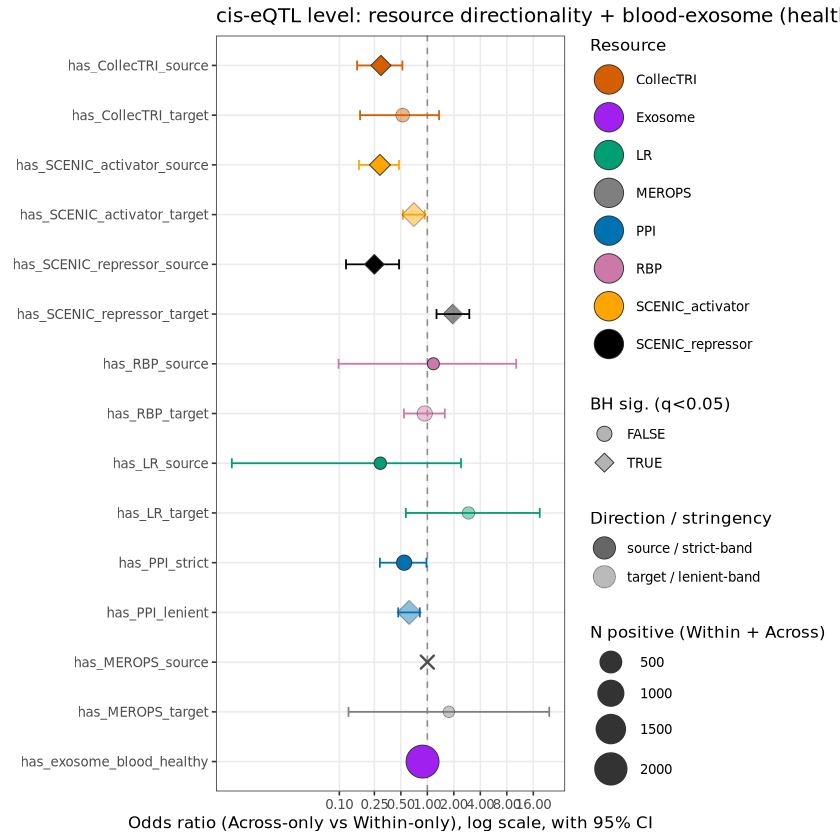

In [27]:
plot_forest_v9_style <- function(dt, row_var, title_text, out_prefix,
                                  colored_by_resource = TRUE, explicit_row_order = NULL) {
  dt_plot <- prep_forest_data(dt)
  if (nrow(dt_plot) == 0) { cat("Nothing to plot for", out_prefix, "\n"); return(invisible(NULL)) }

  if (colored_by_resource && row_var == "category") {
    dt_plot[, resource := category_resource_map[category]]
    dt_plot[, direction := category_direction_map[category]]
  }

  ## explicit_row_order is given TOP-to-BOTTOM (reading order, e.g. TF first,
  ## exosome last). ggplot's scale_*_discrete(limits=...) places the FIRST
  ## element of `limits` at the BOTTOM of a y-axis - so the bottom-to-top
  ## axis order is simply the reverse of the top-to-bottom reading order.
  ## (Previous version reversed twice by mistake, which cancelled out and put
  ## exosome at the top instead of the bottom - fixed here by computing the
  ## bottom-to-top order once, directly, with no second reversal.)
  if (!is.null(explicit_row_order)) {
    row_order_top_to_bottom <- explicit_row_order[explicit_row_order %in% dt_plot[[row_var]]]
  } else {
    row_order_top_to_bottom <- c(
      dt_plot[is_zero_hit == FALSE][order(-odds_ratio)][[row_var]],
      dt_plot[is_zero_hit == TRUE][[row_var]]
    )
  }
  axis_limits_bottom_to_top <- rev(row_order_top_to_bottom)

  dt_plot[[row_var]] <- factor(dt_plot[[row_var]], levels = axis_limits_bottom_to_top)

  p <- ggplot(dt_plot, aes(x = odds_ratio, y = .data[[row_var]]))

  if (colored_by_resource && row_var == "category") {
    p <- p +
      geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
      geom_errorbar(aes(xmin = ci_low, xmax = ci_high, color = resource),
                    orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
      geom_point(
        data = dt_plot[is_zero_hit == FALSE],
        aes(size = n_pos, fill = resource, shape = sig_BH_05, alpha = direction),
        color = "grey20", stroke = 0.4
      ) +
      scale_fill_manual(values = resource_colors, name = "Resource") +
      scale_color_manual(values = resource_colors, guide = "none") +
      scale_alpha_manual(values = c("source/strict" = 1, "target/lenient" = 0.45),
                          name = "Direction / stringency", labels = c("source / strict-band", "target / lenient-band")) +
      guides(
        fill  = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20", alpha = 1), order = 1),
        shape = guide_legend(override.aes = list(size = 4, fill = "grey70"), order = 2),
        alpha = guide_legend(override.aes = list(size = 6, fill = "grey40", shape = 21, colour = "grey20"), order = 3)
      )
  } else {
    p <- p +
      geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
      geom_errorbar(aes(xmin = ci_low, xmax = ci_high),
                    orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
      geom_point(
        data = dt_plot[is_zero_hit == FALSE],
        aes(size = n_pos, shape = sig_BH_05), fill = "steelblue", color = "grey20", stroke = 0.4
      )
  }

  p <- p +
    geom_point(
      data = dt_plot[is_zero_hit == TRUE],
      aes(x = 1), shape = 4, size = 3, color = "grey30", stroke = 1
    ) +
    scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
    scale_size_continuous(name = "N positive (Within + Across)", range = c(3, 9)) +
    scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                  labels = scales::label_number(accuracy = 0.01)) +
    scale_y_discrete(limits = axis_limits_bottom_to_top) +
    labs(
      x = "Odds ratio (Across-only vs Within-only), log scale, with 95% CI",
      y = NULL,
      title = title_text
    ) +
    theme_bw(base_size = 10) +
    theme(axis.text.y = element_text(size = 8), panel.grid.minor = element_blank())

  ggsave(paste0(outdir, out_prefix, ".png"), p, width = 9, height = max(3, 0.4 * nrow(dt_plot) + 1.5), dpi = 200, bg = "white")
  ggsave(paste0(outdir, out_prefix, ".pdf"), p, width = 9, height = max(3, 0.4 * nrow(dt_plot) + 1.5), bg = "white")
  ggsave(paste0(outdir, out_prefix, ".svg"), p, width = 9, height = max(3, 0.4 * nrow(dt_plot) + 1.5), bg = "white")
  p
}

p1 <- plot_forest_v9_style(cis_eqtl_fisher_all, "category",
                            "cis-eQTL level: resource directionality + blood-exosome (healthy) enrichment",
                            "cis_eqtl_level_forest", explicit_row_order = category_row_order)
p1

# SAVE

In [28]:
## =============================================================================
## 8. Save results + plotting metadata for reuse in a different notebook
## =============================================================================
plot_metadata <- list(
  resource_colors         = resource_colors,
  category_resource_map   = category_resource_map,
  category_direction_map  = category_direction_map,
  category_row_order      = category_row_order,   # top-to-bottom reading order used for cis-eQTL level plot
  pattern_row_order       = pattern_names,          # top-to-bottom reading order used for pattern-level plot

  ## Filter thresholds actually used to build has_exosome_blood_healthy,
  ## so a later notebook can confirm which definition these results reflect
  ## without re-deriving it from the raw exoRBase file.
  min_healthy_evp_n    = min_healthy_evp_n,
  min_healthy_evp_freq = min_healthy_evp_freq,
  exosome_source_file  = exosome_path,
  exosome_definition   = "Gene passes if round(healthy_evp_freq * healthy_evp_n_cohort) >= min_healthy_evp_n AND healthy_evp_freq >= min_healthy_evp_freq (healthy_evp_n_cohort is a fixed blood-healthy-EVP cohort size, NOT a per-gene detection count - see exo_gene_level$max_healthy_evp_n_detected)",

  odds_ratio_convention = "OR = odds(category present | Across-only) / odds(category present | Within-only). Computed via factor(edge_type_composition, levels=c('Within-only','Across-only')) before table() to fix row order explicitly - do not rely on alphabetical table() ordering.",

  generated_on = Sys.time(),
  r_session    = capture.output(sessionInfo())
)

results_bundle <- list(
  cis_eqtl_fisher_all      = cis_eqtl_fisher_all,
  pattern_exosome_results  = pattern_exosome_results,
  cis_eqtl_factors         = cis_eqtl_factors,     # underlying per-factor annotation table, for re-deriving anything
  plot_metadata            = plot_metadata,
  prep_forest_data         = prep_forest_data,      # saved as a closure so plotting is fully reproducible elsewhere
  plot_forest_v9_style     = plot_forest_v9_style
)

saveRDS(results_bundle, file = paste0(outdir, "cis_eqtl_exosome_results_bundle.rds"))

## Human-readable companions alongside the RDS bundle
fwrite(cis_eqtl_fisher_all, paste0(outdir, "cis_eqtl_level_fisher_results.tsv"), sep = "\t")
fwrite(pattern_exosome_results, paste0(outdir, "pattern_level_exosome_fisher_results.tsv"), sep = "\t")

metadata_flat <- data.table(
  field = names(plot_metadata)[!names(plot_metadata) %in% c("resource_colors", "category_resource_map",
                                                              "category_direction_map", "category_row_order",
                                                              "pattern_row_order", "r_session")],
  value = sapply(plot_metadata[!names(plot_metadata) %in% c("resource_colors", "category_resource_map",
                                                              "category_direction_map", "category_row_order",
                                                              "pattern_row_order", "r_session")], as.character)
)
fwrite(metadata_flat, paste0(outdir, "plot_metadata_summary.tsv"), sep = "\t")

cat("Saved bundle to:", paste0(outdir, "cis_eqtl_exosome_results_bundle.rds"), "\n")
cat("Saved companions: cis_eqtl_level_fisher_results.tsv, pattern_level_exosome_fisher_results.tsv, plot_metadata_summary.tsv\n")

Saved bundle to: /nfs/team151/mt19/overhaul_classification_factors_with_programs/cis_eQTL_level_exosome/cis_eqtl_exosome_results_bundle.rds 
Saved companions: cis_eqtl_level_fisher_results.tsv, pattern_level_exosome_fisher_results.tsv, plot_metadata_summary.tsv
